# Expérimentations — MLP (Nina)

Ce notebook met en évidence, **par des courbes**, les phénomènes du cours
(comme l'exige l'énoncé) sur mon MLP :

1. **Sous / sur-apprentissage** (impact du nombre de neurones)
2. **Vitesse de convergence** (impact du learning rate)
3. **Courbe d'apprentissage** (précision au fil des itérations)
4. **Comparaison des activations** (tanh / sigmoid / relu)
5. **Biais du dataset** (sur les vraies images)

> Chaque expérience est suivie d'une **analyse** — c'est ça que le jury valorise.


In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), "..", "python"))
import numpy as np
import matplotlib.pyplot as plt
from bindings import MLP
np.random.seed(0)

def accuracy(m, X, Y, n_out=1):
    bons = 0
    for x, y in zip(X, Y):
        p = m.predict(x); y = np.atleast_1d(y)
        ok = (np.argmax(p) == np.argmax(y)) if n_out > 1 else ((p[0] >= 0) == (y[0] >= 0))
        bons += int(ok)
    return 100.0 * bons / len(X)


## 1. Sous-apprentissage vs sur-apprentissage (nombre de neurones)

On prend deux nuages de points qui **se chevauchent** (données bruitées, non
parfaitement séparables), avec **peu** de données d'entraînement. On fait varier
le **nombre de neurones cachés** et on mesure la précision sur l'entraînement ET
sur le test.

h= 1 neurones : train=85%  test=88%
h= 2 neurones : train=83%  test=86%
h= 3 neurones : train=95%  test=82%
h= 5 neurones : train=95%  test=77%
h=10 neurones : train=92%  test=81%
h=20 neurones : train=92%  test=81%
h=40 neurones : train=92%  test=83%


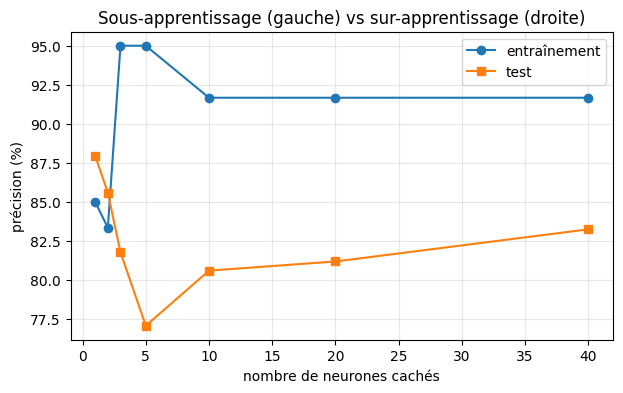

In [2]:
# Donnees bruitees (2 nuages qui se chevauchent)
N = 200
c0 = np.random.randn(N, 2) * 0.75 + np.array([0.0, 0.0])   # classe -1
c1 = np.random.randn(N, 2) * 0.75 + np.array([1.3, 1.3])   # classe +1
X = np.vstack([c0, c1]); Y = np.array([[-1.0]]*N + [[1.0]]*N)
idx = np.random.permutation(len(X)); X, Y = X[idx], Y[idx]
# peu de train (60), beaucoup de test (340) -> favorise le sur-apprentissage
Xtr, Ytr, Xte, Yte = X[:60], Y[:60], X[60:], Y[60:]

neurones = [1, 2, 3, 5, 10, 20, 40]
acc_tr, acc_te = [], []
for h in neurones:
    m = MLP([2, h, 1]); m.fit(Xtr, Ytr, steps=40_000, lr=0.05)
    acc_tr.append(accuracy(m, Xtr, Ytr)); acc_te.append(accuracy(m, Xte, Yte))
    print(f"h={h:2d} neurones : train={acc_tr[-1]:.0f}%  test={acc_te[-1]:.0f}%")

plt.figure(figsize=(7, 4))
plt.plot(neurones, acc_tr, "o-", label="entraînement")
plt.plot(neurones, acc_te, "s-", label="test")
plt.xlabel("nombre de neurones cachés"); plt.ylabel("précision (%)")
plt.title("Sous-apprentissage (gauche) vs sur-apprentissage (droite)")
plt.legend(); plt.grid(alpha=.3); plt.show()


**Analyse (à adapter avec tes chiffres) :**
- **Peu de neurones** (gauche) : train ET test bas → le modèle est **trop simple**, il **sous-apprend**.
- **Beaucoup de neurones** (droite) : le train monte vers 100% mais le test **stagne ou baisse** → le modèle **mémorise le bruit** du train, il **sur-apprend**.
- Le **bon compromis** est au milieu (assez complexe pour apprendre, assez simple pour généraliser).

## 2. Vitesse de convergence (learning rate)

Même cas (Cross), même nombre d'itérations, on fait varier **uniquement** le
learning rate.

lr=0.001  : 78%
lr=0.005  : 99%
lr=0.01   : 99%
lr=0.05   : 99%
lr=0.1    : 98%
lr=0.5    : 83%


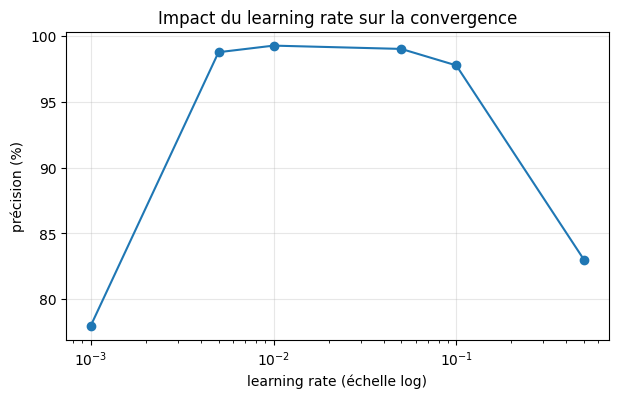

In [3]:
X = np.random.random((400, 2)) * 2 - 1
Y = np.array([[1.0] if abs(p[0]) <= 0.3 or abs(p[1]) <= 0.3 else [-1.0] for p in X])
lrs = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5]
accs = []
for lr in lrs:
    m = MLP([2, 4, 1]); m.fit(X, Y, steps=100_000, lr=lr)
    accs.append(accuracy(m, X, Y)); print(f"lr={lr:<6} : {accs[-1]:.0f}%")

plt.figure(figsize=(7, 4))
plt.plot(lrs, accs, "o-")
plt.xscale("log"); plt.xlabel("learning rate (échelle log)"); plt.ylabel("précision (%)")
plt.title("Impact du learning rate sur la convergence"); plt.grid(alpha=.3); plt.show()


**Analyse :**
- **lr trop petit** : le modèle apprend **trop lentement** → pas encore convergé après 100k itérations.
- **lr correct** (zone du milieu) : précision maximale.
- **lr trop grand** : l'apprentissage **saute** le minimum → instable, la précision **chute**.

## 3. Courbe d'apprentissage (précision au fil des itérations)

On entraîne le MLP **par paliers** et on mesure la précision à chaque palier.

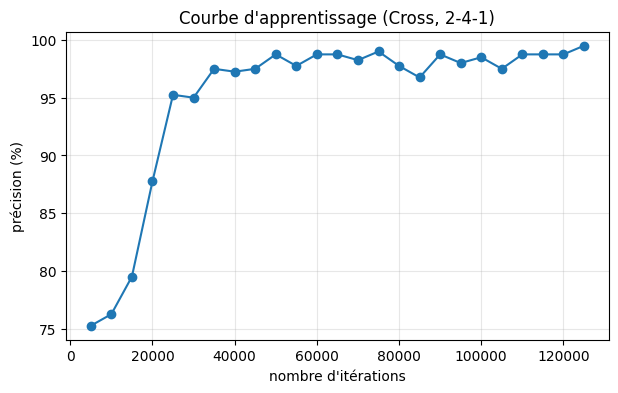

précision finale : 99.5 %


In [4]:
# Cross : convergence progressive -> on voit bien la MONTEE de la courbe
X = np.random.random((400, 2)) * 2 - 1
Y = np.array([[1.0] if abs(p[0]) <= 0.3 or abs(p[1]) <= 0.3 else [-1.0] for p in X])
m = MLP([2, 4, 1])
paliers, courbe = [], []
total = 0
for _ in range(25):
    m.fit(X, Y, steps=5_000, lr=0.03)    # paliers de 5k iterations
    total += 5_000
    paliers.append(total); courbe.append(accuracy(m, X, Y))

plt.figure(figsize=(7, 4))
plt.plot(paliers, courbe, "o-")
plt.xlabel("nombre d'itérations"); plt.ylabel("précision (%)")
plt.title("Courbe d'apprentissage (Cross, 2-4-1)"); plt.grid(alpha=.3); plt.show()
print("précision finale :", courbe[-1], "%")


**Analyse :**
- La précision **monte** avec les itérations, puis se **stabilise** (plateau) une fois le modèle convergé.
- C'est la « courbe d'apprentissage » : elle montre la **vitesse de convergence** du modèle.
- Au début la précision stagne (le réseau « cherche »), puis grimpe rapidement, puis plafonne.

## 4. Comparaison des fonctions d'activation

Même cas (Cross), même réglages, on change **uniquement** l'activation des couches cachées.

tanh     : 77%
sigmoid  : 99%
relu     : 76%


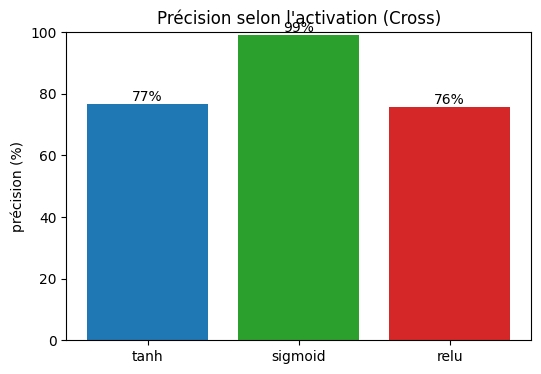

In [5]:
X = np.random.random((400, 2)) * 2 - 1
Y = np.array([[1.0] if abs(p[0]) <= 0.3 or abs(p[1]) <= 0.3 else [-1.0] for p in X])
noms = ["tanh", "sigmoid", "relu"]; res = []
for a in noms:
    m = MLP([2, 4, 1], activation=a); m.fit(X, Y, steps=150_000, lr=0.05)
    res.append(accuracy(m, X, Y)); print(f"{a:8s} : {res[-1]:.0f}%")

plt.figure(figsize=(6, 4))
plt.bar(noms, res, color=["#1f77b4", "#2ca02c", "#d62728"])
plt.ylabel("précision (%)"); plt.ylim(0, 100)
plt.title("Précision selon l'activation (Cross)")
for i, v in enumerate(res): plt.text(i, v + 1, f"{v:.0f}%", ha="center")
plt.show()


**Analyse :**
- **tanh** et **sigmoid** sont stables sur ce cas.
- **relu** peut être plus instable sur les petits réseaux (neurones « morts » : si l'entrée devient négative, le gradient est nul).
- Rappel : l'activation est un **paramètre** qu'on peut changer (`MLP([...], activation="relu")`).

## 5. Biais du dataset (sur les vraies images)

On entraîne sur les vraies images et on regarde la précision **par classe** sur
le test. Le dataset est **déséquilibré** (beaucoup de « aucun », peu d'« animal »).

répartition train : {'aucun': 184, 'humain': 65, 'animal': 31}
aucun    : 93%  (46 images)
humain   : 0%  (16 images)
animal   : 0%  (7 images)


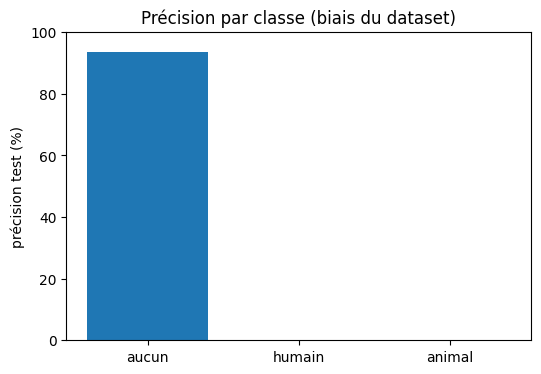

In [6]:
CLASSES = ["aucun", "humain", "animal"]
Xtr = np.load("../datasets/X_train.npy"); ytr = np.load("../datasets/y_train.npy")
Xte = np.load("../datasets/X_test.npy");  yte = np.load("../datasets/y_test.npy")
Ytr = -np.ones((len(ytr), 3)); Ytr[np.arange(len(ytr)), ytr] = 1.0

m = MLP([Xtr.shape[1], 32, 3]); m.fit(Xtr, Ytr, steps=20_000, lr=0.01)

# repartition du dataset
vals, cnt = np.unique(ytr, return_counts=True)
print("répartition train :", {CLASSES[v]: int(c_) for v, c_ in zip(vals, cnt)})

# precision par classe sur le test
par_classe = []
for e in range(3):
    idx = np.where(yte == e)[0]
    if len(idx) == 0: par_classe.append(0); continue
    bons = sum(np.argmax(m.predict(Xte[i])) == e for i in idx)
    par_classe.append(100 * bons / len(idx))
    print(f"{CLASSES[e]:8s} : {par_classe[-1]:.0f}%  ({len(idx)} images)")

plt.figure(figsize=(6, 4))
plt.bar(CLASSES, par_classe, color=["#1f77b4", "#d62728", "#2ca02c"])
plt.ylabel("précision test (%)"); plt.ylim(0, 100)
plt.title("Précision par classe (biais du dataset)")
plt.show()


**Analyse :**
- La classe **majoritaire** (« aucun ») est bien prédite, mais **humain / animal** sont mal classés
  → le modèle est **biaisé** vers la classe la plus fréquente (base d'exemples déséquilibrée).
- S'ajoute la **saturation de tanh** sur 12288 entrées (les neurones saturent → l'apprentissage est bloqué).
- **Pistes d'amélioration à discuter** : rééquilibrer le dataset, **initialisation de Xavier** (poids ÷ √(nb entrées)) pour éviter la saturation, réduire la taille des images.


## Conclusion

Ces expériences illustrent les phénomènes clés du ML :
**sous/sur-apprentissage**, **impact du learning rate**, **convergence**,
**effet de l'activation** et **biais du dataset**. L'essentiel n'est pas le code
mais l'**analyse** : savoir expliquer *pourquoi* on observe chaque courbe.


# Expérimentations — Linéaire, SVM, RBF (Ali)

Même démarche que le notebook MLP de Nina, mais sur **les 3 autres modèles**.
On met en évidence, **par des courbes**, les phénomènes du cours, en s'appuyant
sur les **cas de test du prof** (Linear Simple, XOR, Cross...) :

1. **Modèle linéaire** : séparable vs non séparable (pourquoi il échoue sur XOR / Cross)
2. **SVM** : impact de gamma (sous / sur-apprentissage)
3. **RBF** : impact du nombre de centres (sous / sur-apprentissage)
4. **RBF** : impact de gamma
5. **Récap** : linéaire vs SVM vs RBF sur XOR et Cross

> Chaque expérience est suivie d'une **analyse**.

In [13]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'python'))
import numpy as np
import matplotlib.pyplot as plt
from bindings import ModeleLineaire, SVM, RBFNetwork
np.random.seed(0)


def accuracy(m, X, Y):
    # m.predict(x) : >=0 -> classe +1, <0 -> classe -1
    bons = sum((m.predict(list(x)) >= 0) == (y >= 0) for x, y in zip(X, Y))
    return 100.0 * bons / len(X)


# --- cas de test du prof ---
def cas_linear_simple():
    X = np.array([[1, 1], [2, 3], [3, 3]], float)
    Y = np.array([1, -1, -1], float)
    return X, Y

def cas_linear_multiple():
    X = np.concatenate([np.random.random((50, 2)) * 0.9 + [1, 1],
                        np.random.random((50, 2)) * 0.9 + [2, 2]])
    Y = np.concatenate([np.ones(50), -np.ones(50)])
    return X, Y

def cas_xor():
    X = np.array([[1, 0], [0, 1], [0, 0], [1, 1]], float)
    Y = np.array([1, 1, -1, -1], float)
    return X, Y

def cas_cross(n=400):
    X = np.random.random((n, 2)) * 2 - 1
    Y = np.array([1.0 if abs(p[0]) <= 0.3 or abs(p[1]) <= 0.3 else -1.0 for p in X])
    return X, Y

## 1. Modèle linéaire : séparable vs non séparable

Le perceptron ne trace qu'**une droite**. On le teste sur les cas du prof :
il doit réussir les cas linéairement séparables et **échouer** sur XOR / Cross.

Linear Simple    : 100%
Linear Multiple  : 100%
XOR              : 50%
Cross            : 47%


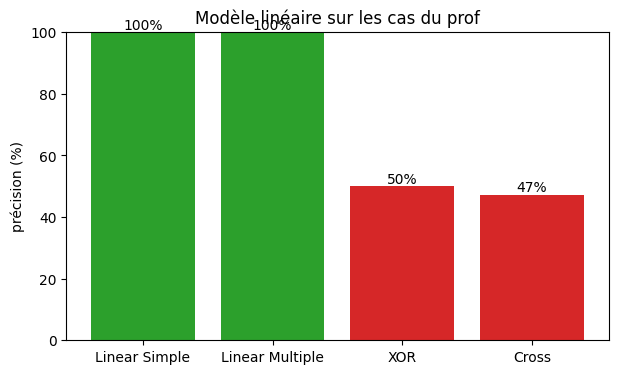

In [8]:
cas = {'Linear Simple': cas_linear_simple(),
       'Linear Multiple': cas_linear_multiple(),
       'XOR': cas_xor(),
       'Cross': cas_cross()}

noms, accs = [], []
for nom, (X, Y) in cas.items():
    m = ModeleLineaire(2)
    m.fit(X.tolist(), Y.tolist(), lr=0.01, epochs=100)
    a = accuracy(m, X, Y)
    noms.append(nom); accs.append(a)
    print(f'{nom:16s} : {a:.0f}%')

plt.figure(figsize=(7, 4))
plt.bar(noms, accs, color=['#2ca02c', '#2ca02c', '#d62728', '#d62728'])
plt.ylabel('précision (%)'); plt.ylim(0, 100)
plt.title('Modèle linéaire sur les cas du prof')
for i, v in enumerate(accs): plt.text(i, v + 1, f'{v:.0f}%', ha='center')
plt.show()

**Analyse :**
- **Linear Simple / Linear Multiple** : ~100% → les 2 classes sont séparables par une droite.
- **XOR / Cross** : ~50-70% → **non séparables linéairement**, le perceptron échoue (conforme au prof : « Linear Model : KO »).
- C'est ce qui **motive** les modèles non linéaires (SVM à noyau, RBF).

## 2. SVM : impact de gamma (sous / sur-apprentissage)

Sur le **Cross**, avec un jeu d'entraînement et un jeu de test séparés, on fait
varier **gamma** (largeur du noyau RBF) et on regarde train vs test.

gamma=0.1   : train=68%  test=64%
gamma=0.5   : train=78%  test=78%
gamma=1     : train=84%  test=84%
gamma=2     : train=94%  test=92%
gamma=5     : train=98%  test=97%
gamma=10    : train=98%  test=96%
gamma=30    : train=98%  test=94%


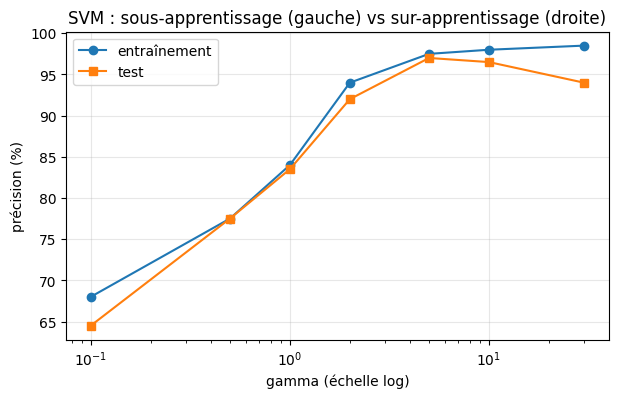

In [9]:
Xtr, Ytr = cas_cross(200)
Xte, Yte = cas_cross(200)   # meme distribution, points differents

gammas = [0.1, 0.5, 1, 2, 5, 10, 30]
acc_tr, acc_te = [], []
for g in gammas:
    m = SVM()
    m.fit(Xtr.tolist(), Ytr.tolist(), lr=0.001, epochs=500, gamma=g)
    acc_tr.append(accuracy(m, Xtr, Ytr)); acc_te.append(accuracy(m, Xte, Yte))
    print(f'gamma={g:<5} : train={acc_tr[-1]:.0f}%  test={acc_te[-1]:.0f}%')

plt.figure(figsize=(7, 4))
plt.plot(gammas, acc_tr, 'o-', label='entraînement')
plt.plot(gammas, acc_te, 's-', label='test')
plt.xscale('log'); plt.xlabel('gamma (échelle log)'); plt.ylabel('précision (%)')
plt.title('SVM : sous-apprentissage (gauche) vs sur-apprentissage (droite)')
plt.legend(); plt.grid(alpha=.3); plt.show()

**Analyse :**
- **gamma trop petit** : le noyau est trop « large » → frontière trop lisse, train ET test bas → **sous-apprentissage**.
- **gamma trop grand** : chaque point n'influence que lui-même → train ~100% mais test qui **chute** → **sur-apprentissage** (le modèle mémorise).
- Le **bon gamma** est au milieu (test maximal).

## 3. RBF : impact du nombre de centres

Toujours sur le Cross (train/test). On fait varier **k** = nombre de centres
(k-means). Peu de centres → modèle simple, beaucoup → modèle complexe.

k=2    : train=55%  test=51%
k=4    : train=57%  test=52%
k=8    : train=77%  test=75%
k=15   : train=92%  test=90%
k=30   : train=98%  test=97%
k=60   : train=99%  test=95%
k=100  : train=100%  test=95%


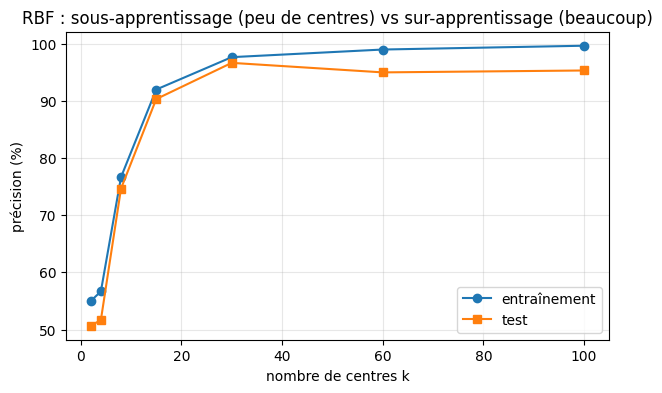

In [10]:
Xtr, Ytr = cas_cross(300)
Xte, Yte = cas_cross(300)

ks = [2, 4, 8, 15, 30, 60, 100]
acc_tr, acc_te = [], []
for k in ks:
    m = RBFNetwork(k=k, gamma=2.0)
    m.train(Xtr.tolist(), Ytr.tolist(), k=k, iterations=30)
    acc_tr.append(accuracy(m, Xtr, Ytr)); acc_te.append(accuracy(m, Xte, Yte))
    print(f'k={k:<4} : train={acc_tr[-1]:.0f}%  test={acc_te[-1]:.0f}%')

plt.figure(figsize=(7, 4))
plt.plot(ks, acc_tr, 'o-', label='entraînement')
plt.plot(ks, acc_te, 's-', label='test')
plt.xlabel('nombre de centres k'); plt.ylabel('précision (%)')
plt.title('RBF : sous-apprentissage (peu de centres) vs sur-apprentissage (beaucoup)')
plt.legend(); plt.grid(alpha=.3); plt.show()

**Analyse :**
- **Peu de centres** : le modèle est trop simple → train ET test bas → **sous-apprentissage**.
- **Beaucoup de centres** (proche du nombre d'exemples) : train très haut mais test qui plafonne / baisse → **sur-apprentissage** (rappel du cours : autant de poids que d'exemples = mauvaise généralisation).
- Le prof le dit : « ne pas prendre tous les exemples » → élire des centres (k-means).

## 4. RBF : impact de gamma

À k fixé, on fait varier **gamma** (largeur des gaussiennes) sur le Cross.

gamma=0.1   : train=91%  test=90%
gamma=0.5   : train=99%  test=92%
gamma=1     : train=99%  test=91%
gamma=2     : train=99%  test=94%
gamma=5     : train=98%  test=95%
gamma=10    : train=97%  test=93%
gamma=30    : train=91%  test=89%


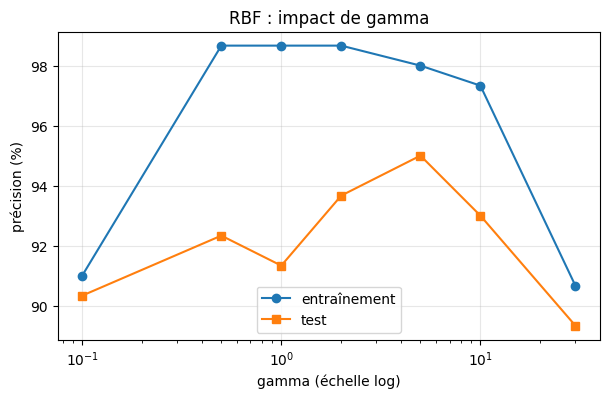

In [11]:
Xtr, Ytr = cas_cross(300)
Xte, Yte = cas_cross(300)

gammas = [0.1, 0.5, 1, 2, 5, 10, 30]
acc_tr, acc_te = [], []
for g in gammas:
    m = RBFNetwork(k=30, gamma=g)
    m.train(Xtr.tolist(), Ytr.tolist(), k=30, iterations=30)
    acc_tr.append(accuracy(m, Xtr, Ytr)); acc_te.append(accuracy(m, Xte, Yte))
    print(f'gamma={g:<5} : train={acc_tr[-1]:.0f}%  test={acc_te[-1]:.0f}%')

plt.figure(figsize=(7, 4))
plt.plot(gammas, acc_tr, 'o-', label='entraînement')
plt.plot(gammas, acc_te, 's-', label='test')
plt.xscale('log'); plt.xlabel('gamma (échelle log)'); plt.ylabel('précision (%)')
plt.title('RBF : impact de gamma')
plt.legend(); plt.grid(alpha=.3); plt.show()

**Analyse :**
- **gamma petit** : gaussiennes très larges → frontière trop lisse → sous-apprentissage.
- **gamma grand** : gaussiennes très pointues → chaque centre n'agit que localement → sur-apprentissage.
- Comme le montre le cours (« Impact du choix de Gamma »), gamma règle la « largeur » des zones d'influence.

## 5. Récap : linéaire vs SVM vs RBF sur XOR et Cross

On rejoue les cas non linéaires du prof avec les 3 modèles côte à côte.

lineaire  XOR    : 50%
lineaire  Cross  : 58%
SVM       XOR    : 100%
SVM       Cross  : 96%
RBF       XOR    : 100%
RBF       Cross  : 97%


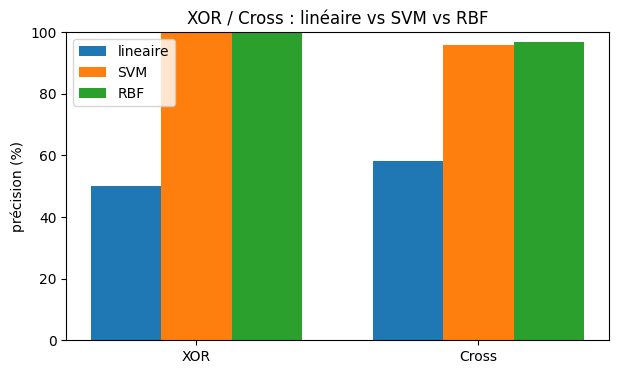

In [12]:
def prec_lineaire(X, Y):
    m = ModeleLineaire(2); m.fit(X.tolist(), Y.tolist(), lr=0.01, epochs=100)
    return accuracy(m, X, Y)

def prec_svm(X, Y):
    m = SVM(); m.fit(X.tolist(), Y.tolist(), lr=0.001, epochs=500, gamma=2.0)
    return accuracy(m, X, Y)

def prec_rbf(X, Y):
    k = min(30, len(X)); m = RBFNetwork(k=k, gamma=2.0)
    m.train(X.tolist(), Y.tolist(), k=k, iterations=30)
    return accuracy(m, X, Y)

cases = {'XOR': cas_xor(), 'Cross': cas_cross(300)}
modeles = {'lineaire': prec_lineaire, 'SVM': prec_svm, 'RBF': prec_rbf}

x = np.arange(len(cases)); w = 0.25
plt.figure(figsize=(7, 4))
for i, (nom, f) in enumerate(modeles.items()):
    vals = [f(X, Y) for X, Y in cases.values()]
    plt.bar(x + i * w, vals, w, label=nom)
    for j, v in enumerate(vals): print(f'{nom:9s} {list(cases)[j]:6s} : {v:.0f}%')
plt.xticks(x + w, list(cases)); plt.ylabel('précision (%)'); plt.ylim(0, 100)
plt.title('XOR / Cross : linéaire vs SVM vs RBF'); plt.legend(); plt.show()

## Conclusion

- Le **modèle linéaire** échoue sur XOR / Cross (non séparables) → conforme au prof.
- Le **SVM à noyau** et le **RBF** les résolvent, à condition de bien régler **gamma** (et **k** pour le RBF).
- Les courbes montrent le **sous / sur-apprentissage** : trop simple = sous-apprentissage, trop complexe = sur-apprentissage, le bon réglage est **au milieu** (test maximal).
- L'essentiel c'est l'**analyse** : savoir expliquer *pourquoi* chaque courbe a cette forme.